# Entrenamiento de Modelos

## Carga de infomracion

In [1]:
import pandas as pd

#dataset_oot_final = pd.read_csv("../data/dataset_oot_final.csv")
traintest = pd.read_csv("../data/dataset_final_train.csv")

C:\Users\jormora\AppData\Local\Temp\ipykernel_24316\2811296646.py:4: DtypeWarning: Columns (0: marca_pago_AJUSTES_BANCO, 1: marca_pago_CANCELADO, 2: marca_pago_FACTURACION_MES_SGTE, 3: marca_pago_IGUAL, 4: marca_pago_NO_PAGO, 5: marca_pago_PAGO_MAS, 6: marca_pago_PAGO_MENOS, 7: marca_pago_SIN_FACTURACION, 8: producto_ANTICIPOS, 9: producto_CARTERA MICROCREDITO, 10: producto_CARTERA ORDINARIA, 11: producto_CREDIPAGO, 12: producto_Cartera Consumo, 13: producto_Cartera Microcredito, 14: producto_HIPOTECARIO VIVIENDA, 15: producto_LEASING, 16: producto_LEASING HABITACIONAL, 17: producto_LIBRANZA, 18: producto_LIBRE INVERSION, 19: producto_OTROS HIPOTECARIO, 20: producto_ROTATIVOS, 21: producto_SOBREGIRO, 22: producto_Sobregiro, 23: producto_TARJETA DE CREDITO, 24: producto_TESORERIA, 25: producto_Tarjeta de Crédito, 26: producto_Titularizada, 27: segmento_EMPRESARIAL, 28: segmento_GOBIERNO DE RED, 29: segmento_MICROPYME, 30: segmento_PERSONAL, 31: segmento_PERSONAL PLUS, 32: segmento_PREFE

In [2]:
# Meses distintos presentes en traintest, ordenados cronologicamente
periodos = (
    traintest[["year", "month"]]
    .drop_duplicates()
    .sort_values(["year", "month"])
    .reset_index(drop=True)
)

n_meses_test = 1
periodos_train = periodos.iloc[:-n_meses_test]
periodos_test = periodos.iloc[-n_meses_test:]

# Primeros meses para entrenar, ultimos n_meses_test meses para probar
train = traintest.merge(periodos_train, on=["year", "month"], how="inner")
test = traintest.merge(periodos_test, on=["year", "month"], how="inner")

print(f"Meses train: {list(periodos_train.itertuples(index=False, name=None))}")
print(f"Meses test: {list(periodos_test.itertuples(index=False, name=None))}")
print(f"train: {train.shape}, test: {test.shape}")

Meses train: [(2023, 7), (2023, 8), (2023, 9), (2023, 10)]
Meses test: [(2023, 11)]
train: (467785, 394), test: (100466, 394)


## Busqueda de hiperparametros con Optuna (arbol de decision / random forest)

Se limpian los dtypes (columnas one-hot leidas como texto), se optimiza un modelo simple con Optuna
sobre `train` evaluando AUC-ROC en `test` (split cronologico ya realizado), y finalmente se entrena el
mejor modelo para analizar la importancia de variables (`feature_importances_`).

In [18]:
# Columnas one-hot leidas del CSV como object (mezcla de True/False y 0/1)
import numpy as np

target = "var_rpta_alt"
columnas_no_features = ["nit_enmascarado", "num_oblig_enmascarado", "year", "month"]


def limpiar_dtypes(df):
    df = df.copy()
    for col in df.columns:
        # No numericas/booleanas (incluye object y el dtype "str" que usa pandas al leer el csv)
        es_no_numerica = not (
            pd.api.types.is_numeric_dtype(df[col]) or pd.api.types.is_bool_dtype(df[col])
        )
        if es_no_numerica and col not in columnas_no_features:
            # Normaliza a texto primero: la columna puede mezclar bool nativo y strings "True"/"False"
            df[col] = df[col].astype(str).str.strip().replace({"True": "1", "False": "0"})
            df[col] = pd.to_numeric(df[col], errors="coerce")
    # Algunas variables (ej. porcentajes) quedaron con inf por divisiones; se tratan como nulos
    df = df.replace([np.inf, -np.inf], np.nan)
    return df.fillna(0)


train_modelo = limpiar_dtypes(train)
test_modelo = limpiar_dtypes(test)

X_train = train_modelo.drop(columns=columnas_no_features + [target])
y_train = train_modelo[target]
X_test = test_modelo.drop(columns=columnas_no_features + [target])
y_test = test_modelo[target]

X_train.shape, X_test.shape

((467785, 389), (100466, 389))

In [4]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

MODELO = "random_forest"  # "random_forest" o "arbol_decision"


def crear_modelo(trial):
    if MODELO == "random_forest":
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
            "max_depth": trial.suggest_int("max_depth", 3, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "random_state": 42,
            "n_jobs": -1,
        }
        return RandomForestClassifier(**params)
    else:
        params = {
            "max_depth": trial.suggest_int("max_depth", 2, 20),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
            "random_state": 42,
        }
        return DecisionTreeClassifier(**params)


def objective(trial):
    modelo = crear_modelo(trial)
    modelo.fit(X_train, y_train)
    proba = modelo.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, proba)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15, show_progress_bar=True)

print("Mejor AUC:", study.best_value)
print("Mejores hiperparametros:", study.best_params)

c:\Users\jormora\Documents\Documentos\prueba_tecnica\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-09-12 00:33:32,979] A new study created in memory with name: no-name-c4ef2bb0-0bc1-4099-812c-56f9ec65477f
Best trial: 0. Best value: 0.700211:   7%|▋         | 1/15 [00:34<08:00, 34.29s/it]

[I 2026-09-12 00:34:07,271] Trial 0 finished with value: 0.7002114641936077 and parameters: {'n_estimators': 200, 'max_depth': 13, 'min_samples_split': 14, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 0 with value: 0.7002114641936077.


Best trial: 0. Best value: 0.700211:  13%|█▎        | 2/15 [01:03<06:47, 31.35s/it]

[I 2026-09-12 00:34:36,560] Trial 1 finished with value: 0.6805492923331936 and parameters: {'n_estimators': 300, 'max_depth': 7, 'min_samples_split': 20, 'min_samples_leaf': 13, 'max_features': 'log2'}. Best is trial 0 with value: 0.7002114641936077.


Best trial: 0. Best value: 0.700211:  20%|██        | 3/15 [22:12<1:59:16, 596.38s/it]

...

[I 2026-09-12 01:13:20,398] Trial 12 finished with value: 0.711529721924294 and parameters: {'n_estimators': 150, 'max_depth': 19, 'min_samples_split': 14, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 11 with value: 0.7115472299241901.


Best trial: 11. Best value: 0.711547:  93%|█████████▎| 14/15 [41:15<01:38, 98.64s/it] 

[I 2026-09-12 01:14:48,052] Trial 13 finished with value: 0.7104642200383604 and parameters: {'n_estimators': 200, 'max_depth': 18, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 11 with value: 0.7115472299241901.


Best trial: 14. Best value: 0.711857: 100%|██████████| 15/15 [42:20<00:00, 169.39s/it]

[I 2026-09-12 01:15:53,837] Trial 14 finished with value: 0.7118569667971619 and parameters: {'n_estimators': 150, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 14 with value: 0.7118569667971619.
Mejor AUC: 0.7118569667971619
Mejores hiperparametros: {'n_estimators': 150, 'max_depth': 19, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt'}


### Importancia de variables del mejor modelo

Se reentrena el modelo con los mejores hiperparametros encontrados por Optuna y se grafican las
variables con mayor `feature_importances_`, para identificar cuales impactan mas en la clasificacion.

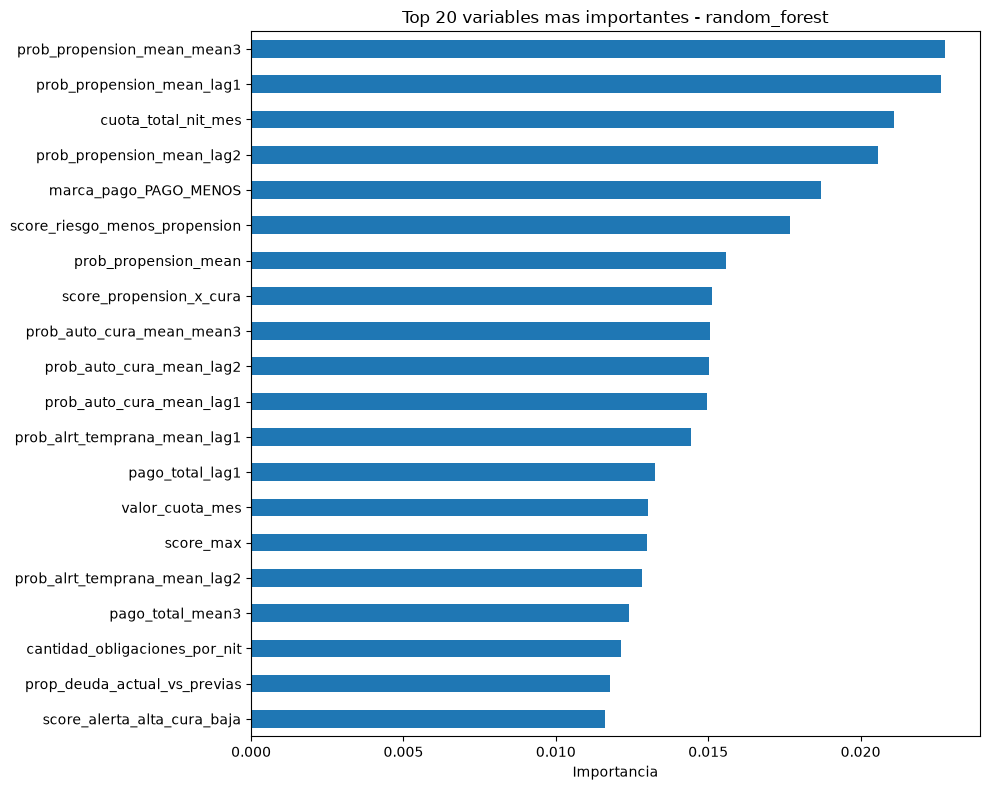

prob_propension_mean_mean3       0.022779
prob_propension_mean_lag1        0.022645
cuota_total_nit_mes              0.021095
prob_propension_mean_lag2        0.020555
marca_pago_PAGO_MENOS            0.018716
score_riesgo_menos_propension    0.017669
prob_propension_mean             0.015593
score_propension_x_cura          0.015139
prob_auto_cura_mean_mean3        0.015065
prob_auto_cura_mean_lag2         0.015031
prob_auto_cura_mean_lag1         0.014957
prob_alrt_temprana_mean_lag1     0.014431
pago_total_lag1                  0.013259
valor_cuota_mes                  0.013012
score_max                        0.012996
prob_alrt_temprana_mean_lag2     0.012814
pago_total_mean3                 0.012413
cantidad_obligaciones_por_nit    0.012137
prop_deuda_actual_vs_previas     0.011780
score_alerta_alta_cura_baja      0.011626
dtype: float64

In [5]:
import matplotlib.pyplot as plt

mejor_modelo = crear_modelo(optuna.trial.FixedTrial(study.best_params))
mejor_modelo.fit(X_train, y_train)

importancias = (
    pd.Series(mejor_modelo.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

top_n = 20
plt.figure(figsize=(10, 8))
importancias.head(top_n).sort_values().plot(kind="barh")
plt.title(f"Top {top_n} variables mas importantes - {MODELO}")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

importancias.head(top_n)

In [6]:
importancias[importancias > 0.001].count()

np.int64(137)

### Busqueda exhaustiva con Optuna sobre variables relevantes

Se reduce el dataset a las 64 variables con `feature_importances_ > 0.001` del modelo anterior, y se
amplia la busqueda de Optuna para que tambien elija el tipo de modelo (`random_forest`, `extra_trees`,
`arbol_decision`, `gradient_boosting`, `regresion_logistica`) con rangos de hiperparametros mas abiertos.

In [19]:
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

columnas_relevantes = importancias[importancias > 0.001].index.tolist()
X_train_top = X_train[columnas_relevantes]
X_test_top = X_test[columnas_relevantes]

print(f"Variables relevantes: {len(columnas_relevantes)} de {X_train.shape[1]}")


def crear_modelo_amplio(trial):
    tipo_modelo = trial.suggest_categorical(
        "tipo_modelo",
        ["random_forest", "extra_trees", "gradient_boosting", "regresion_logistica"],
    )

    if tipo_modelo in ("random_forest", "extra_trees"):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
            "max_depth": trial.suggest_int("max_depth", 10, 30),
            "min_samples_split": trial.suggest_int("min_samples_split", 5, 35),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "criterion": trial.suggest_categorical("criterion_bosque", ["gini", "entropy"]),
            "random_state": 42,
            "n_jobs": -1,
        }
        clase = RandomForestClassifier if tipo_modelo == "random_forest" else ExtraTreesClassifier
        return clase(**params)

    if tipo_modelo == "gradient_boosting":
        params = {
            "n_estimators": trial.suggest_int("n_estimators_gb", 50, 300, step=50),
            "max_depth": trial.suggest_int("max_depth_gb", 2, 8),
            "learning_rate": trial.suggest_float("learning_rate_gb", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample_gb", 0.5, 1.0),
            "min_samples_split": trial.suggest_int("min_samples_split_gb", 2, 30),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf_gb", 1, 30),
            "random_state": 42,
        }
        return GradientBoostingClassifier(**params)

    # regresion_logistica
    params = {
        "C": trial.suggest_float("C_logreg", 1e-3, 100, log=True),
        "penalty": "l2",
        "solver": "lbfgs",
        "max_iter": 1000,
        "random_state": 42,
    }
    return LogisticRegression(**params)


def objective_amplio(trial):
    modelo = crear_modelo_amplio(trial)
    modelo.fit(X_train_top, y_train)
    proba = modelo.predict_proba(X_test_top)[:, 1]
    return roc_auc_score(y_test, proba)


study_amplio = optuna.create_study(direction="maximize")
# timeout como salvavidas: se detiene al llegar a 40 trials o 30 minutos, lo que ocurra primero
study_amplio.optimize(objective_amplio, n_trials=40, timeout=7200, show_progress_bar=True)

print("Mejor AUC:", study_amplio.best_value)
print("Mejores hiperparametros:", study_amplio.best_params)

[I 2026-09-12 08:54:13,187] A new study created in memory with name: no-name-4743d083-9dac-4931-8529-c3e8c8796272


Variables relevantes: 137 de 389


Best trial: 0. Best value: 0.708894:   2%|▎         | 1/40 [18:36<12:05:43, 1116.50s/it, 1116.50/7200 seconds]c:\Users\jormora\Documents\Documentos\prueba_tecnica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[I 2026-09-12 09:12:49,690] Trial 0 finished with value: 0.7088936234669072 and parameters: {'tipo_modelo': 'extra_trees', 'n_estimators': 350, 'max_depth': 19, 'min_samples_split': 12, 'min_samples_leaf': 6, 'max_features': None, 'criterion_bosque': 'entropy'}. Best is trial 0 with value: 0.7088936234669072.


c:\Users\jormora\Documents\Documentos\prueba_tecnica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Best trial: 0. Best value: 0.708894:   5%|▌         | 2/40 [20:29<5:33:15, 526.19s/it, 1229.48/7200 seconds]  c:\Users\jormora\Documents\Documentos\prueba_tecnica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value a

...

[I 2026-09-12 10:51:32,867] Trial 5 finished with value: 0.7097197929181283 and parameters: {'tipo_modelo': 'gradient_boosting', 'n_estimators_gb': 300, 'max_depth_gb': 8, 'learning_rate_gb': 0.06886717579120025, 'subsample_gb': 0.7558739249523787, 'min_samples_split_gb': 10, 'min_samples_leaf_gb': 24}. Best is trial 5 with value: 0.7097197929181283.


Best trial: 5. Best value: 0.70972:  18%|█▊        | 7/40 [1:59:15<12:44:42, 1390.37s/it, 7155.26/7200 seconds]c:\Users\jormora\Documents\Documentos\prueba_tecnica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


[I 2026-09-12 10:53:28,444] Trial 6 finished with value: 0.6895462540035542 and parameters: {'tipo_modelo': 'extra_trees', 'n_estimators': 300, 'max_depth': 16, 'min_samples_split': 9, 'min_samples_leaf': 13, 'max_features': 'sqrt', 'criterion_bosque': 'gini'}. Best is trial 5 with value: 0.7097197929181283.


c:\Users\jormora\Documents\Documentos\prueba_tecnica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
Best trial: 5. Best value: 0.70972:  20%|██        | 8/40 [2:01:32<8:06:09, 911.55s/it, 7292.40/7200 seconds]  

[I 2026-09-12 10:55:45,579] Trial 7 finished with value: 0.5890883882026986 and parameters: {'tipo_modelo': 'regresion_logistica', 'C_logreg': 0.023948358041961756}. Best is trial 5 with value: 0.7097197929181283.
Mejor AUC: 0.7097197929181283
Mejores hiperparametros: {'tipo_modelo': 'gradient_boosting', 'n_estimators_gb': 300, 'max_depth_gb': 8, 'learning_rate_gb': 0.06886717579120025, 'subsample_gb': 0.7558739249523787, 'min_samples_split_gb': 10, 'min_samples_leaf_gb': 24}


                          max      mean  count
tipo_modelo                                   
gradient_boosting    0.709720  0.709720      1
extra_trees          0.708894  0.696287      3
random_forest        0.703260  0.703260      1
regresion_logistica  0.589170  0.589090      3


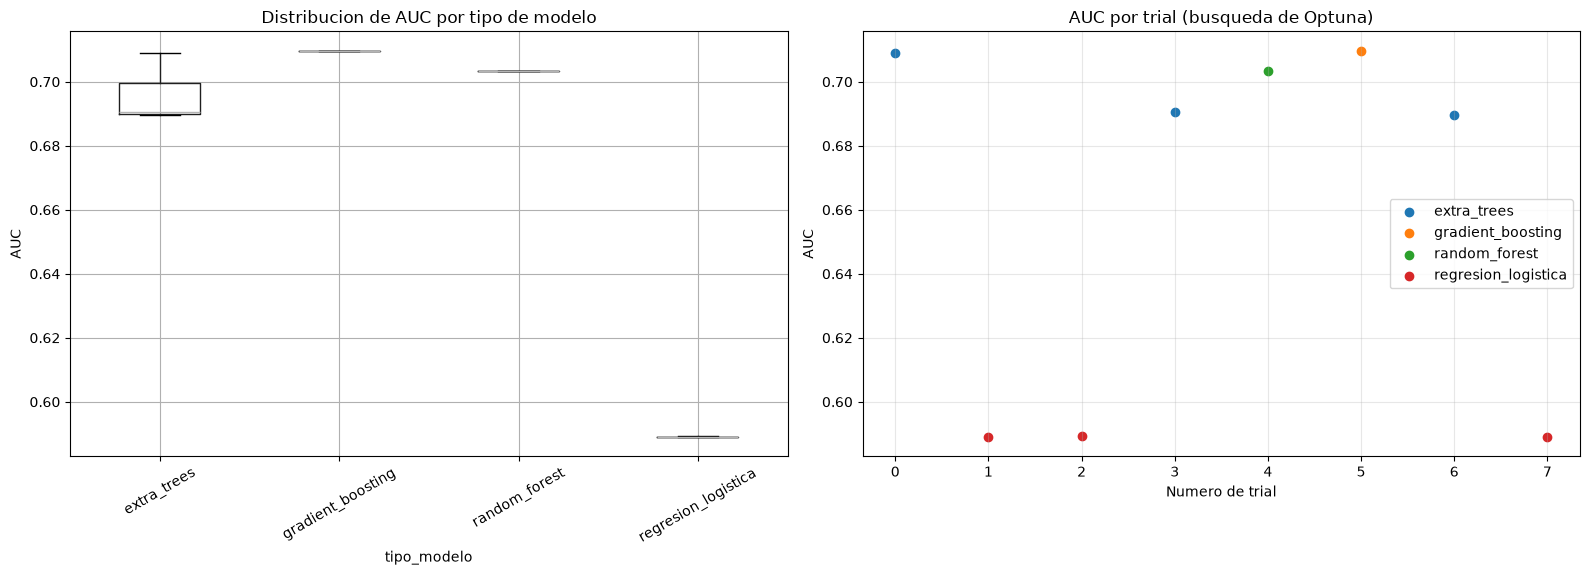

In [20]:
# Resultados de todos los trials de la busqueda amplia, uno por tipo de modelo
resultados = study_amplio.trials_dataframe()
resultados = resultados[resultados["state"] == "COMPLETE"].copy()
resultados = resultados.rename(columns={"value": "auc", "params_tipo_modelo": "tipo_modelo"})

mejor_por_modelo = (
    resultados.groupby("tipo_modelo")["auc"]
    .agg(["max", "mean", "count"])
    .sort_values("max", ascending=False)
)
print(mejor_por_modelo)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribucion de AUC obtenido por cada tipo de modelo a lo largo de los trials
resultados.boxplot(column="auc", by="tipo_modelo", ax=axes[0], rot=30)
axes[0].set_title("Distribucion de AUC por tipo de modelo")
axes[0].set_xlabel("tipo_modelo")
axes[0].set_ylabel("AUC")

# Evolucion del AUC a lo largo de los trials, coloreado por tipo de modelo
for tipo_modelo, grupo in resultados.groupby("tipo_modelo"):
    axes[1].scatter(grupo["number"], grupo["auc"], label=tipo_modelo)
axes[1].set_title("AUC por trial (busqueda de Optuna)")
axes[1].set_xlabel("Numero de trial")
axes[1].set_ylabel("AUC")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("")
plt.tight_layout()
plt.show()

In [21]:
import joblib
from pathlib import Path

# Los hiperparametros de study_amplio se ajustaron sobre columnas_relevantes (X_train_top),
# por lo que el modelo final debe entrenarse con ese mismo subconjunto de columnas
mejor_modelo = crear_modelo_amplio(optuna.trial.FixedTrial(study_amplio.best_params))
mejor_modelo.fit(X_train_top, y_train)

modelos_dir = Path("../models")
modelos_dir.mkdir(exist_ok=True)

# Nombre dinamico: incluye el tipo de modelo y el AUC obtenido en la busqueda
tipo_modelo = study_amplio.best_params["tipo_modelo"]
auc = study_amplio.best_value
nombre_modelo = f"modelo_{tipo_modelo}_auc_{auc:.4f}.pkl"
ruta_modelo = modelos_dir / nombre_modelo

# Mismo esquema que el modelo normalizado (columnas usadas), sin scaler porque no se normalizo
joblib.dump({"modelo": mejor_modelo, "scaler": None, "columnas": columnas_relevantes}, ruta_modelo)

print(f"Modelo guardado en {ruta_modelo.resolve()}")

Modelo guardado en C:\Users\jormora\Documents\Documentos\prueba_tecnica\models\modelo_gradient_boosting_auc_0.7097.pkl


### Mismo experimento con datos normalizados

Se repite la busqueda amplia de Optuna sobre las mismas variables relevantes y el mismo espacio de
modelos, pero normalizando con `StandardScaler` ajustado unicamente en `train` y aplicado (transform)
tanto a `train` como a `test`, para evitar fuga de informacion.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_top_norm = pd.DataFrame(
    scaler.fit_transform(X_train_top), columns=columnas_relevantes, index=X_train_top.index
)
# El scaler se ajusta solo con train; test se transforma con esos mismos parametros
X_test_top_norm = pd.DataFrame(
    scaler.transform(X_test_top), columns=columnas_relevantes, index=X_test_top.index
)


def objective_amplio_normalizado(trial):
    modelo = crear_modelo_amplio(trial)
    modelo.fit(X_train_top_norm, y_train)
    proba = modelo.predict_proba(X_test_top_norm)[:, 1]
    return roc_auc_score(y_test, proba)


study_amplio_normalizado = optuna.create_study(direction="maximize")
study_amplio_normalizado.optimize(
    objective_amplio_normalizado, n_trials=40, timeout=7200, show_progress_bar=True
)

print("Mejor AUC (normalizado):", study_amplio_normalizado.best_value)
print("Mejores hiperparametros:", study_amplio_normalizado.best_params)

[I 2026-09-12 04:08:44,515] A new study created in memory with name: no-name-d6fd1085-2e8a-4e9a-a8a3-63b6a1755de7
  0%|          | 0/40 [00:00<?, ?it/s]c:\Users\jormora\Documents\Documentos\prueba_tecnica\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
Best trial: 0. Best value: 0.667165:   2%|▎         | 1/40 [00:08<05:35,  8.59s/it, 8.59/7200 seconds]

[I 2026-09-12 04:08:53,106] Trial 0 finished with value: 0.667164743641975 and parameters: {'tipo_modelo': 'regresion_logistica', 'C_logreg': 0.0021290896946791872}. Best is trial 0 with value: 0.667164743641975.


Best trial: 0. Best value: 0.667165:   5%|▌         | 2/40 [00:31<10:49, 17.09s/it, 31.63/7200 seconds]

[I 2026-09-12 04:09:16,142] Trial 1 finished with value: 0.6547444502185924 and parameters: {'tipo_modelo': 'arbol_decision', 'max_depth_arbol': 6, 'min_samples_split_arbol': 17, 'min_samples_leaf_arbol': 3, 'criterion_arbol': 'log_loss'}. Best is trial 0 with value: 0.667164743641975.


Best trial: 2. Best value: 0.669925:   8%|▊         | 3/40 [05:51<1:35:51, 155.43s/it, 351.69/7200 seconds]

...

[I 2026-09-12 05:33:51,265] Trial 9 finished with value: 0.7013187892317116 and parameters: {'tipo_modelo': 'extra_trees', 'n_estimators': 200, 'max_depth': 15, 'min_samples_split': 25, 'min_samples_leaf': 22, 'max_features': None, 'criterion_bosque': 'gini'}. Best is trial 8 with value: 0.7100895505117815.


Best trial: 8. Best value: 0.71009:  28%|██▊       | 11/40 [1:36:52<5:05:29, 632.06s/it, 5812.23/7200 seconds]

[I 2026-09-12 05:45:36,740] Trial 10 finished with value: 0.6408896463709707 and parameters: {'tipo_modelo': 'random_forest', 'n_estimators': 500, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'criterion_bosque': 'entropy'}. Best is trial 8 with value: 0.7100895505117815.


Best trial: 8. Best value: 0.71009:  30%|███       | 12/40 [2:13:45<5:12:07, 668.83s/it, 8025.90/7200 seconds] 

[I 2026-09-12 06:22:30,418] Trial 11 finished with value: 0.6992904066392684 and parameters: {'tipo_modelo': 'gradient_boosting', 'n_estimators_gb': 300, 'max_depth_gb': 3, 'learning_rate_gb': 0.0688361480549017, 'subsample_gb': 0.8108434103777975, 'min_samples_split_gb': 7, 'min_samples_leaf_gb': 18}. Best is trial 8 with value: 0.7100895505117815.
Mejor AUC (normalizado): 0.7100895505117815
Mejores hiperparametros: {'tipo_modelo': 'extra_trees', 'n_estimators': 350, 'max_depth': 25, 'min_samples_split': 11, 'min_samples_leaf': 5, 'max_features': None, 'criterion_bosque': 'entropy'}


                          max      mean  count
tipo_modelo                                   
extra_trees          0.710090  0.694061      5
gradient_boosting    0.701920  0.700605      2
regresion_logistica  0.667165  0.667165      1
arbol_decision       0.654744  0.631468      3
random_forest        0.640890  0.640890      1


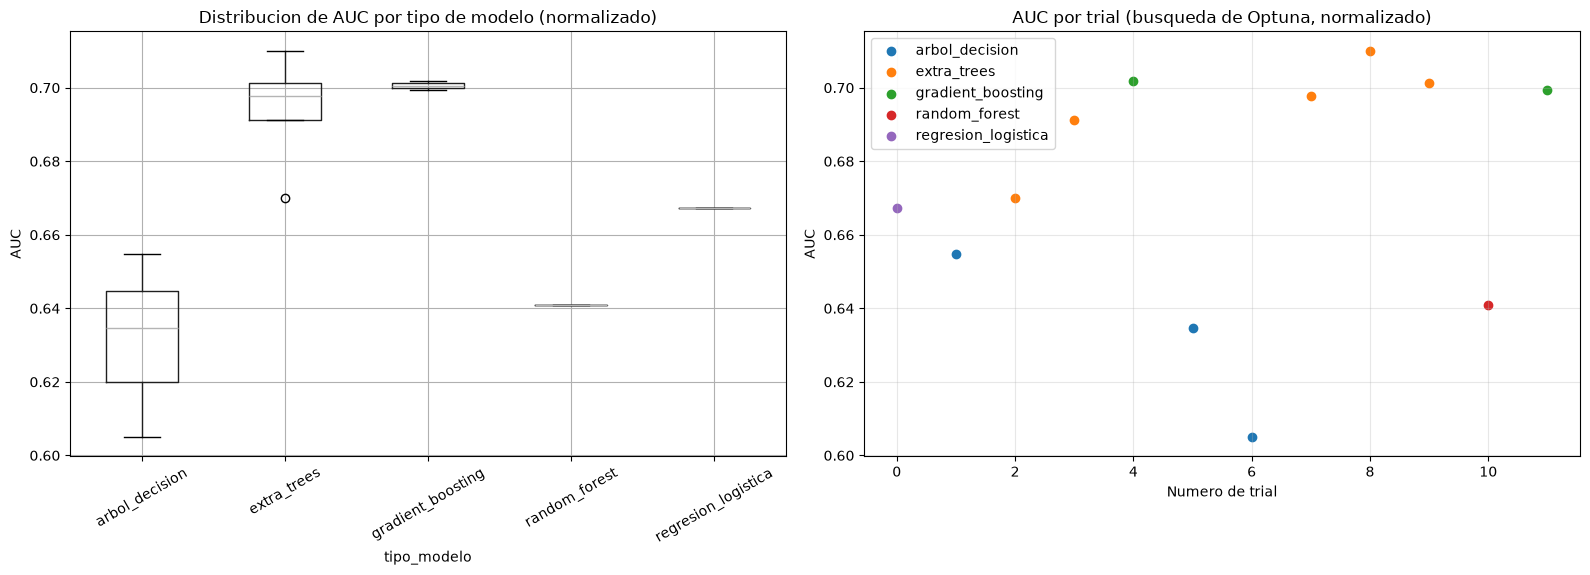

In [11]:
# Resultados de todos los trials de la busqueda con datos normalizados, uno por tipo de modelo
resultados_norm = study_amplio_normalizado.trials_dataframe()
resultados_norm = resultados_norm[resultados_norm["state"] == "COMPLETE"].copy()
resultados_norm = resultados_norm.rename(columns={"value": "auc", "params_tipo_modelo": "tipo_modelo"})

mejor_por_modelo_norm = (
    resultados_norm.groupby("tipo_modelo")["auc"]
    .agg(["max", "mean", "count"])
    .sort_values("max", ascending=False)
)
print(mejor_por_modelo_norm)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribucion de AUC obtenido por cada tipo de modelo a lo largo de los trials (datos normalizados)
resultados_norm.boxplot(column="auc", by="tipo_modelo", ax=axes[0], rot=30)
axes[0].set_title("Distribucion de AUC por tipo de modelo (normalizado)")
axes[0].set_xlabel("tipo_modelo")
axes[0].set_ylabel("AUC")

# Evolucion del AUC a lo largo de los trials, coloreado por tipo de modelo
for tipo_modelo, grupo in resultados_norm.groupby("tipo_modelo"):
    axes[1].scatter(grupo["number"], grupo["auc"], label=tipo_modelo)
axes[1].set_title("AUC por trial (busqueda de Optuna, normalizado)")
axes[1].set_xlabel("Numero de trial")
axes[1].set_ylabel("AUC")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("")
plt.tight_layout()
plt.show()

### Guardar el mejor modelo (datos normalizados)

Se entrena de nuevo el mejor modelo encontrado por `study_amplio_normalizado` (usando los datos
normalizados) y se guarda con el mismo esquema usado para el mejor modelo sin normalizar: el nombre
del archivo incluye el tipo de modelo y el AUC obtenido en la busqueda.

In [12]:
import joblib
from pathlib import Path

# Mismo esquema de guardado anterior, pero para el mejor modelo con datos normalizados
mejor_modelo_norm = crear_modelo_amplio(optuna.trial.FixedTrial(study_amplio_normalizado.best_params))
mejor_modelo_norm.fit(X_train_top_norm, y_train)

modelos_dir = Path("../models")
modelos_dir.mkdir(exist_ok=True)

# Nombre dinamico: incluye el tipo de modelo y el AUC obtenido en la busqueda
tipo_modelo_norm = study_amplio_normalizado.best_params["tipo_modelo"]
auc_norm = study_amplio_normalizado.best_value
nombre_modelo_norm = f"modelo_{tipo_modelo_norm}_normalizado_auc_{auc_norm:.4f}.pkl"
ruta_modelo_norm = modelos_dir / nombre_modelo_norm

# Se guarda tambien el scaler y las columnas usadas, necesarios para preparar el input en inferencia
joblib.dump(
    {"modelo": mejor_modelo_norm, "scaler": scaler, "columnas": columnas_relevantes},
    ruta_modelo_norm,
)

print(f"Modelo guardado en {ruta_modelo_norm.resolve()}")

Modelo guardado en C:\Users\jormora\Documents\Documentos\prueba_tecnica\models\modelo_extra_trees_normalizado_auc_0.7101.pkl


## Prediccion

In [22]:
import joblib
from pathlib import Path

# Nombre del archivo .pkl a cargar desde ../models
nombre_modelo = "modelo_extra_trees_normalizado_auc_0.7101.pkl"
ruta_modelo_elegido = Path("../models") / nombre_modelo

modelo_cargado = joblib.load(ruta_modelo_elegido)
modelo = modelo_cargado["modelo"]
columnas_modelo = modelo_cargado["columnas"]
scaler_modelo = modelo_cargado.get("scaler")

print(f"Modelo cargado: {ruta_modelo_elegido.name}")

Modelo cargado: modelo_extra_trees_normalizado_auc_0.7101.pkl


In [23]:
import numpy as np

columnas_no_features = ["nit_enmascarado", "num_oblig_enmascarado", "num_oblig_orig_enmascarado"]


def limpiar_dtypes(df):
    df = df.copy()
    for col in df.columns:
        # No numericas/booleanas (incluye object y el dtype "str" que usa pandas al leer el csv)
        es_no_numerica = not (
            pd.api.types.is_numeric_dtype(df[col]) or pd.api.types.is_bool_dtype(df[col])
        )
        if es_no_numerica and col not in columnas_no_features:
            # Normaliza a texto primero: la columna puede mezclar bool nativo y strings "True"/"False"
            df[col] = df[col].astype(str).str.strip().replace({"True": "1", "False": "0"})
            df[col] = pd.to_numeric(df[col], errors="coerce")
    # Algunas variables (ej. porcentajes) quedaron con inf por divisiones; se tratan como nulos
    df = df.replace([np.inf, -np.inf], np.nan)
    return df.fillna(0)


test_modelo = limpiar_dtypes(test)
X_test = test_modelo[columnas_modelo]

# El scaler (si el modelo lo requiere) se ajusto solo con train; aqui unicamente se transforma
if scaler_modelo is not None:
    X_test = pd.DataFrame(
        scaler_modelo.transform(X_test), columns=columnas_modelo, index=X_test.index
    )

X_test.shape

(100466, 137)

In [24]:
proba_test = modelo.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

# test_modelo conserva todas las columnas originales (mismo indice que X_test)
resultados_test = test_modelo.copy()
resultados_test["prediccion"] = pred_test
resultados_test["prediccion_correcta"] = (
    resultados_test["prediccion"] == resultados_test["var_rpta_alt"]
).astype(int)

resultados_test.head()

,nit_enmascarado,num_oblig_enmascarado,year,month,var_rpta_alt,valor_cuota_mes,pago_total,fecha_pago_minima,fecha_pago_maxima,porc_pago,...,hist_var_rpta_alt,hist_var_rpta_alt_lag1,hist_var_rpta_alt_lag2,hist_var_rpta_alt_delta1,hist_var_rpta_alt_delta2,hist_var_rpta_alt_accel,hist_var_rpta_alt_mean3,hist_var_rpta_alt_std3,prediccion,prediccion_correcta
0,59412,290775,2023,11,1,442771.0,1330515.0,20231102.0,20231108.0,300.0,...,1,1,1,0,0,0,1.000000,0.00000,1,1
1,277595,34433,2023,11,1,5059121.0,0.0,0.0,0.0,0.0,...,1,1,1,0,0,0,1.000000,0.00000,1,1
2,487939,689862,2023,11,0,850669.0,0.0,0.0,0.0,0.0,...,1,1,1,0,0,0,1.000000,0.00000,0,1
3,464338,268497,2023,11,0,322927.0,323000.0,20231101.0,20231101.0,100.0,...,1,1,0,0,1,-1,0.666667,0.57735,0,1
4,147234,713712,2023,11,0,361715.0,0.0,0.0,0.0,0.0,...,1,0,1,1,-1,2,0.666667,0.57735,0,1


In [25]:
resultados_test.to_csv("resultados_test.csv", index=False)